# AnomalyDetection API Tutorial (Statsmodels GLM + Diagnostics + Isolation Forest)

## Purpose of this notebook

This notebook documents the **internal programming interface (API)** for the fraud/anomaly detection project.
It is meant as a reference that shows:

- what each utility function does,
- what inputs/outputs it expects,
- how the functions connect in a typical workflow.

For the full narrative analysis and final results, see:
- `AnomalyDetection.example.ipynb`

This notebook uses a **small subset of the dataset** for speed (API smoke test), not for final performance reporting.


## Project architecture

This project separates functionality into:

1. `AnomalyDetection_utils.py`  
   Contains reusable utilities for:
   - loading data
   - preprocessing and scaling
   - GLM modeling (statsmodels)
   - residual/influence diagnostics for anomaly detection
   - evaluation metrics + plotting
   - Isolation Forest (unsupervised) utilities

2. Notebooks  
   - `AnomalyDetection.example.ipynb`: full end-to-end analysis + interpretation
   - `AnomalyDetection.API.ipynb`: API reference + usage examples


In [1]:
import os
import numpy as np
import pandas as pd

from AnomalyDetection_utils import (
    load_data,
    basic_eda,
    class_distribution,
    prepare_data,
    fit_glm_statsmodels,
    glm_predict_proba,
    glm_predict_labels,
    compute_glm_diagnostics,
    flag_anomalies_from_diagnostics,
    evaluate_anomaly_flags,
    evaluate_supervised,
    plot_confusion_matrix,
    plot_roc_curve_from_metrics,
    plot_pr_curve_from_metrics,
    fit_isolation_forest,
    evaluate_isolation_forest,
    two_proportion_ztest_flag_rate,
)


## Dataset dependency

This project uses the Kaggle **Credit Card Fraud Detection** dataset (`creditcard.csv`).

To run this notebook successfully:
- Place `creditcard.csv` in the **same folder** as this notebook.

Note: This API notebook uses a small subset of the dataset to keep execution fast.
The full dataset run and final evaluation are demonstrated in `AnomalyDetection.example.ipynb`.


In [2]:
DATA_PATH = os.path.join(os.getcwd(), "creditcard.csv")
df = load_data(DATA_PATH)

# Small subset for API demo speed (not for final evaluation)
df_small = df.iloc[:50_000].reset_index(drop=True)

df_small.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## API: Basic EDA utilities

### `basic_eda(df) -> None`
Prints:
- dataset shape
- missing value counts
- summary statistics

### `class_distribution(df) -> pd.Series`
Prints and plots:
- class counts for `Class` (0 = legit, 1 = fraud)

Premise:
- Fraud datasets are highly imbalanced, so understanding class distribution is essential.


=== Basic EDA ===
Shape: (50000, 31)

Total missing values: 0

Summary statistics:
                Time            V1            V2            V3            V4  \
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000   
mean   28923.779620     -0.242344      0.010316      0.692829      0.185482   
std    13116.563925      1.887731      1.629766      1.508700      1.400009   
min        0.000000    -56.407510    -72.715728    -32.965346     -5.172595   
25%    21893.500000     -0.992599     -0.564348      0.216729     -0.721295   
50%    33471.500000     -0.245008      0.078253      0.795902      0.191131   
75%    38983.000000      1.155544      0.731591      1.430980      1.067868   
max    44299.000000      1.960497     18.183626      4.101716     16.491217   

                 V5            V6            V7            V8            V9  \
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000   
mean      -0.258043      0.105202     -0.12058

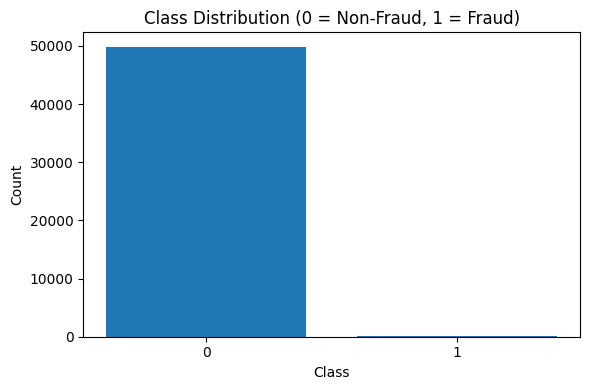

Class
0    49852
1      148
Name: count, dtype: int64

In [3]:
basic_eda(df_small)
class_distribution(df_small)


## API: Data preparation

There are two ways to prepare data:

### Option A (full pipeline): `prepare_data(df, scale_method=...)`
This function performs:
- chronological split by `Time` (80/20)
- scaling (StandardScaler or RobustScaler)
- SMOTE applied ONLY on training data (supervised training)

It returns (7 values):
- `X_train_res, X_test_scaled, y_train_res, y_test, scaler, X_train_scaled, y_train`

### Option B (lightweight demo)
For an API smoke test, we can manually do:
- chronological split
- scaling
without running SMOTE (faster).

In this notebook, we do Option B first for speed, and also show Option A briefly.


In [4]:
from sklearn.preprocessing import StandardScaler

# Time-aware ordering
df_sorted = df_small.sort_values("Time").reset_index(drop=True)

X = df_sorted.drop(columns=["Class"])
y = df_sorted["Class"]

split = int(0.8 * len(X))
X_train_raw, X_test_raw = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

X_train_scaled.shape, X_test_scaled.shape, y_train.shape, y_test.shape


((40000, 30), (10000, 30), (40000,), (10000,))

In [5]:
# Full pipeline API (includes SMOTE internally)
out = prepare_data(df_small, scale_method="standard")

len(out), [type(x) for x in out]



=== After SMOTE (Training Set) ===
Class
0    39896
1    39896
Name: count, dtype: int64


(7,
 [numpy.ndarray,
  numpy.ndarray,
  pandas.core.series.Series,
  pandas.core.series.Series,
  sklearn.preprocessing._data.StandardScaler,
  numpy.ndarray,
  pandas.core.series.Series])

## API: Statistical modeling (Statsmodels GLM)

### `fit_glm_statsmodels(X_train, y_train) -> GLMResults`
Fits a Binomial GLM with logit link (logistic regression) and returns a fitted statsmodels object.

Premise:
- The GLM provides predicted probabilities AND supports model diagnostics.

In this API notebook, we fit on the lightweight pipeline (no SMOTE) purely as an API demonstration.
The final model training workflow (with SMOTE) is in `example.ipynb`.


In [6]:
glm_result = fit_glm_statsmodels(X_train_scaled, y_train)
print(glm_result.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                40000
Model:                            GLM   Df Residuals:                    39969
Model Family:                Binomial   Df Model:                           30
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -180.55
Date:                Mon, 15 Dec 2025   Deviance:                       361.10
Time:                        07:51:28   Pearson chi2:                 1.68e+04
No. Iterations:                    18   Pseudo R-squ. (CS):            0.02675
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.6070      5.048     -2.299      0.0

## API: Prediction utilities

### `glm_predict_proba(glm_result, X) -> np.ndarray`
Returns predicted fraud probabilities.

### `glm_predict_labels(glm_result, X, threshold=0.5) -> (labels, proba)`
Converts probabilities into 0/1 labels using a threshold.


In [7]:
y_proba = glm_predict_proba(glm_result, X_test_scaled)
y_pred, _ = glm_predict_labels(glm_result, X_test_scaled, threshold=0.5)

y_proba[:5], y_pred[:20]


(array([1.70009014e-06, 4.77191955e-07, 1.69257451e-04, 1.26793951e-03,
        1.74292449e-04]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

## API: GLM diagnostics (Residuals + Influence)

### `compute_glm_diagnostics(glm_result, X, y_true) -> dict`
Computes:
- deviance residuals
- Pearson residuals
- standardized versions
- leverage (approx)
- Cook’s distance (approx)

Interpretation (high level):
- large residuals = model fits poorly
- high leverage = unusual feature combination
- high Cook’s distance = influential point


In [8]:
diagnostics = compute_glm_diagnostics(glm_result, X_train_scaled, y_train)

std_dev = diagnostics["std_deviance"]
leverage = diagnostics["leverage"]
cooks_d = diagnostics["cooks_distance"]

std_dev.head(), leverage[:5], cooks_d[:5]


(0   -0.328468
 1   -0.322702
 2   -0.010493
 3   -0.003526
 4   -0.220637
 dtype: float64,
 array([3.00421650e-04, 2.87105149e-04, 2.75648747e-04, 3.11299300e-05,
        1.87884486e-04]),
 array([4.60317882e-09, 4.24590115e-09, 4.30888838e-12, 5.49227523e-14,
        1.29848076e-09]))

## API: Flag anomalies from diagnostics

### `flag_anomalies_from_diagnostics(std_dev_resid, leverage, cooks_d, ...) -> (flags, thresholds)`

Default idea:
- flag extreme residuals
- or very high leverage
- or very high Cook’s distance

Returns:
- `flags`: boolean array (True = anomalous)
- `thresholds`: the actual cutoff values used


In [9]:
flags, thresholds = flag_anomalies_from_diagnostics(
    std_dev_resid=std_dev,
    leverage=leverage,
    cooks_d=cooks_d,
    std_threshold=3.0,
    leverage_quantile=0.99,
    cooks_quantile=0.99,
)

thresholds, flags[:20]


({'std_threshold': 3.0,
  'leverage_cutoff': 0.006930211085807547,
  'cooks_cutoff': 1.8646258961439209e-06},
 array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False]))

## API: Evaluate anomaly flags vs true fraud labels

### `evaluate_anomaly_flags(y_true, anomaly_flags) -> dict`
Treats anomaly flags as predicted fraud labels and reports:
- TP, FP, FN, TN
- precision and recall (fraud class)

Note:
- This API notebook evaluates on training only as a function demonstration.
- Proper held-out evaluation is shown in `example.ipynb`.


In [10]:
anomaly_results = evaluate_anomaly_flags(y_train, flags)
anomaly_results


{'TP': 91,
 'FP': 359,
 'FN': 13,
 'TN': 39537,
 'precision': 0.20222222222222222,
 'recall': 0.875}

## API: Supervised evaluation metrics + plotting

### `evaluate_supervised(y_true, y_proba, threshold=...) -> dict`
Returns:
- precision, recall, f1
- confusion matrix
- arrays for ROC and PR curves

This is useful when the model outputs probabilities and we want both:
- threshold-based metrics
- ranking curves (ROC/PR)


In [11]:
metrics = evaluate_supervised(y_test, y_proba, threshold=0.5)

metrics["confusion_matrix"], metrics["precision"], metrics["recall"], metrics["f1"]


(array([[9956,    0],
        [  13,   31]]),
 1.0,
 0.7045454545454546,
 0.8266666666666667)

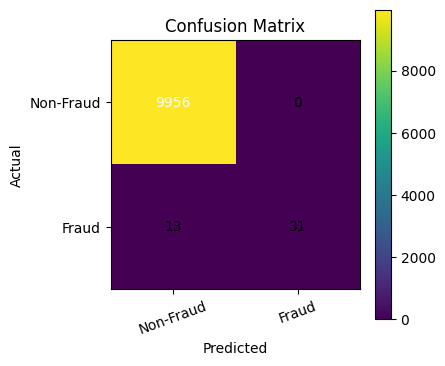

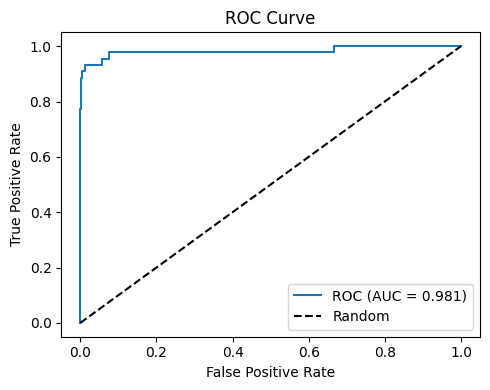

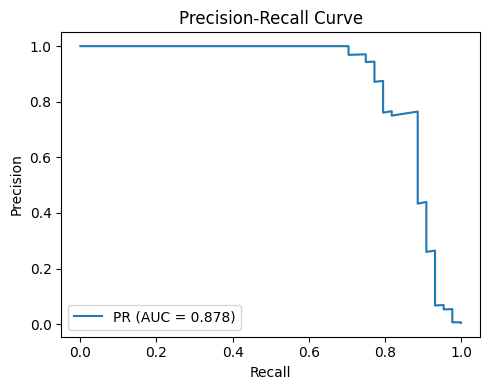

In [12]:
plot_confusion_matrix(metrics["confusion_matrix"])
plot_roc_curve_from_metrics(metrics)
plot_pr_curve_from_metrics(metrics)


## API: Unsupervised anomaly detection (Isolation Forest)

### `fit_isolation_forest(X, ...) -> model`
Fits Isolation Forest without labels.

### `evaluate_isolation_forest(model, X, y_true) -> dict`
Evaluates predicted anomaly labels against true fraud labels and returns:
- precision, recall, f1
- confusion matrix
- ROC/PR curves (using anomaly score)

Important protocol:
- Fit on training data (unlabeled)
- Evaluate on test data (held-out)


In [13]:
iso_model = fit_isolation_forest(X_train_scaled, contamination="auto", random_state=42)
iso_metrics = evaluate_isolation_forest(iso_model, X_test_scaled, y_test)

iso_metrics["confusion_matrix"], iso_metrics["precision"], iso_metrics["recall"], iso_metrics["f1"]


(array([[9539,  417],
        [   1,   43]]),
 0.09347826086956522,
 0.9772727272727273,
 0.17063492063492064)

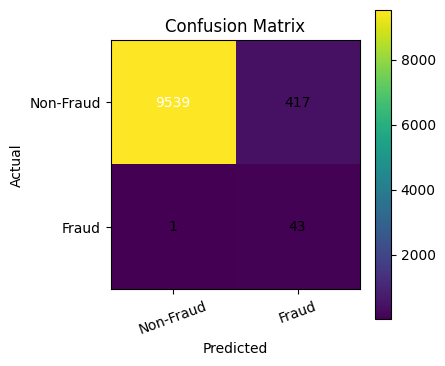

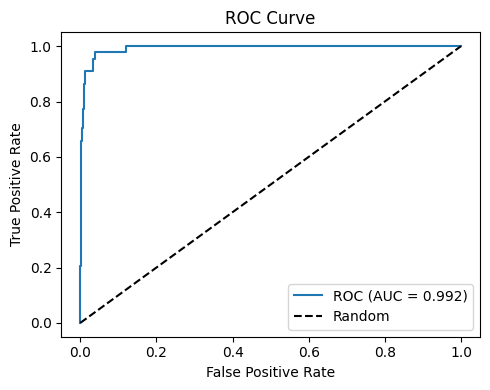

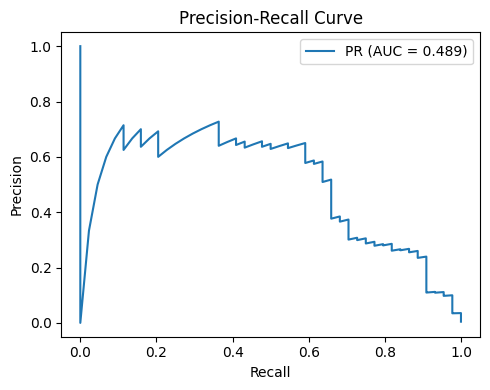

In [14]:
plot_confusion_matrix(iso_metrics["confusion_matrix"])
plot_roc_curve_from_metrics(iso_metrics)
plot_pr_curve_from_metrics(iso_metrics)


## API: Statistical test utility (two-proportion z-test)

### `two_proportion_ztest_flag_rate(y_true, flags) -> dict`
Tests whether fraud transactions are flagged at a higher rate than legitimate ones.

This does not “improve” the model — it provides a formal statistical check that the flagging behavior is associated with fraud labels.


In [15]:
# Diagnostics flags test (train demo)
diag_test = two_proportion_ztest_flag_rate(y_train, flags, alternative="larger")

# Isolation Forest flags test (test evaluation)
if_test = two_proportion_ztest_flag_rate(y_test, iso_metrics["anomaly_flags"], alternative="larger")

diag_test, if_test


({'z': 83.62777432823097,
  'p_value': 0.0,
  'fraud_flag_rate': 0.875,
  'legit_flag_rate': 0.008998395829155806,
  'n_fraud': 104.0,
  'n_legit': 39896.0},
 {'z': 29.55341522889678,
  'p_value': 2.967982645030985e-192,
  'fraud_flag_rate': 0.9772727272727273,
  'legit_flag_rate': 0.04188429087987144,
  'n_fraud': 44.0,
  'n_legit': 9956.0})

## Summary

This notebook is an API reference for the project utilities:
- loading + EDA
- preprocessing/scaling
- GLM modeling + diagnostics-based anomaly flags
- supervised metrics + plotting
- Isolation Forest anomaly detection
- a statistical test helper for flag-rate comparison

For full project narrative and final evaluation, see `AnomalyDetection.example.ipynb`.
